In [57]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/GoldUSD.csv')

# Display the first few rows of the dataset
print(df.head())

       Date        Open        High         Low       Close  Volume
0  30-08-00  273.899994  273.899994  273.899994  273.899994       0
1  31-08-00  274.799988  278.299988  274.799988  278.299988       0
2  01-09-00  277.000000  277.000000  277.000000  277.000000       0
3  05-09-00  275.799988  275.799988  275.799988  275.799988       2
4  06-09-00  274.200012  274.200012  274.200012  274.200012       0


In [58]:
# Display DataFrame info to check data types and non-null values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6399 non-null   object 
 1   Open    6399 non-null   float64
 2   High    6399 non-null   float64
 3   Low     6399 non-null   float64
 4   Close   6399 non-null   float64
 5   Volume  6399 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 300.1+ KB
None


In [59]:
# Convert the 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%y')

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [60]:
# Extract time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['DayOfYear'] = df['Date'].dt.dayofyear

# Create lagged features for 'Close' price
# These represent the closing price from previous days, which are crucial for time series forecasting
df['Close_Lag1'] = df['Close'].shift(1)
df['Close_Lag2'] = df['Close'].shift(2)
df['Close_Lag3'] = df['Close'].shift(3)
df['Close_Lag4'] = df['Close'].shift(4)
df['Close_Lag5'] = df['Close'].shift(5)

# Create daily price change feature
df['Daily_Change'] = df['Close'] - df['Close'].shift(1)

# Create moving average features for 'Close' price
# Moving averages can smooth out short-term fluctuations and highlight longer-term trends
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

# Create volatility feature (7-day rolling standard deviation)
df['Volatility_7D'] = df['Close'].rolling(window=7).std()

# Drop rows with NaN values resulting from lagged features and moving averages
df.dropna(inplace=True)

# Display the first few rows with new features
print("\nDataFrame after feature engineering:")
print(df.head())


DataFrame after feature engineering:
         Date        Open        High         Low       Close  Volume  Year  \
29 2000-10-11  272.500000  273.500000  270.500000  270.500000      18  2000   
30 2000-10-12  274.000000  276.399994  274.000000  276.399994       3  2000   
31 2000-10-13  274.200012  274.200012  272.399994  272.399994       0  2000   
32 2000-10-16  271.500000  271.500000  271.500000  271.500000       5  2000   
33 2000-10-17  271.100006  271.100006  271.100006  271.100006       0  2000   

    Month  Day  DayOfWeek  DayOfYear  Close_Lag1  Close_Lag2  Close_Lag3  \
29     10   11          2        285  272.399994  270.100006  269.299988   
30     10   12          3        286  270.500000  272.399994  270.100006   
31     10   13          4        287  276.399994  270.500000  272.399994   
32     10   16          0        290  272.399994  276.399994  270.500000   
33     10   17          1        291  271.500000  272.399994  276.399994   

    Close_Lag4  Close_Lag5  Da

In [99]:
from sklearn.model_selection import train_test_split

features = ['Open', 'High', 'Low', 'Volume', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear',
            'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag4', 'Close_Lag5', 'Daily_Change', 'MA_7', 'MA_30', 'Volatility_7D',
            'DXY_Close', 'DXY_Lag1', 'DXY_Lag2']
target = 'Close'

X = df[features]
y = df[target]

split_point = int(len(df) * 0.8)

X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5088, 21)
X_test shape: (1272, 21)
y_train shape: (5088,)
y_test shape: (1272,)


In [100]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Random Forest Regressor model
# You can tune hyperparameters like n_estimators, max_depth, etc., for better performance
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
print("\nTraining the Random Forest Regressor model...")
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
print("\nMaking predictions on the test set...")
y_pred = model.predict(X_test)
print("Predictions complete.")

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Training the Random Forest Regressor model...
Model training complete.

Making predictions on the test set...
Predictions complete.

Model Evaluation Metrics:
Mean Absolute Error (MAE): 443.64
Mean Squared Error (MSE): 733199.90
Root Mean Squared Error (RMSE): 856.27
R-squared (R2): -0.13


In [101]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20],   # Maximum depth of the tree
    'min_samples_split': [2, 5]     # Minimum number of samples required to split an internal node
}

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)


print("\nStarting GridSearchCV for hyperparameter tuning...")
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)
print("GridSearchCV complete.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = -grid_search.best_score_  # Convert negative MSE to positive MSE

print(f"\nBest Hyperparameters found: {best_params}")
print(f"Best Cross-validation MSE: {best_score:.2f}")

# Use the best estimator to make predictions on the test set
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

# Evaluate the tuned model
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = mse_tuned**0.5
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"\nTunned Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"R-squared (R2): {r2_tuned:.2f}")


Starting GridSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
GridSearchCV complete.

Best Hyperparameters found: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-validation MSE: 26438.20

Tunned Model Evaluation Metrics:
Mean Absolute Error (MAE): 443.95
Mean Squared Error (MSE): 734314.46
Root Mean Squared Error (RMSE): 856.92
R-squared (R2): -0.13


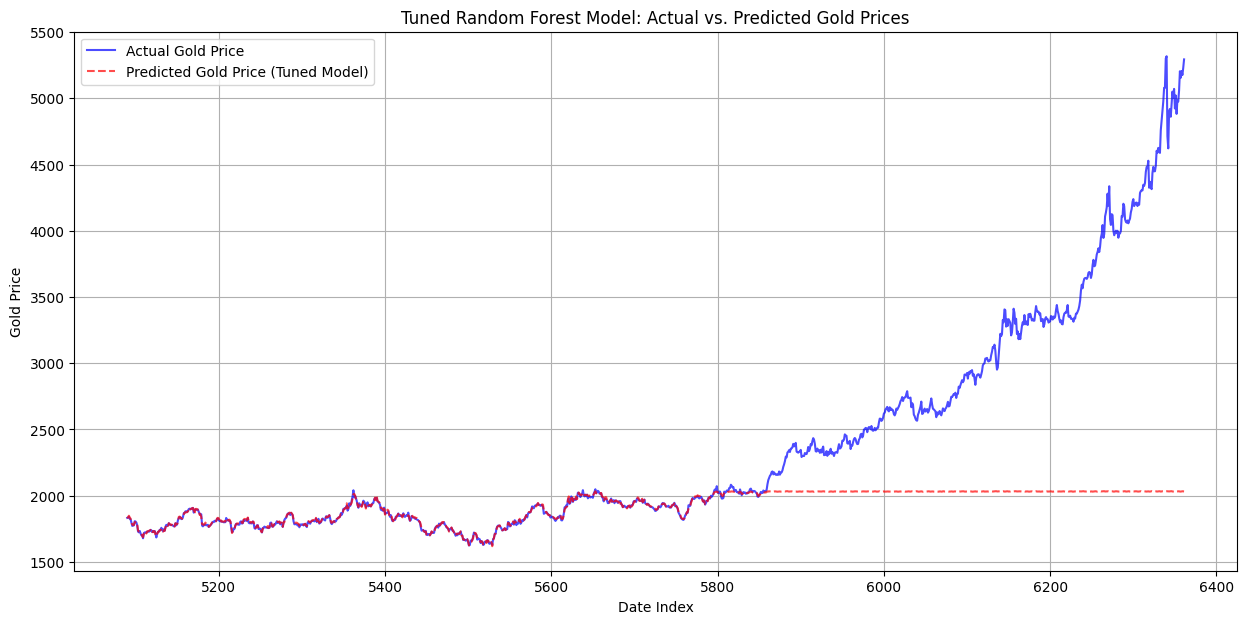

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Actual Gold Price', color='blue', alpha=0.7)
plt.plot(y_test.index, y_pred_tuned, label='Predicted Gold Price (Tuned Model)', color='red', alpha=0.7, linestyle='--')
plt.title('Tuned Random Forest Model: Actual vs. Predicted Gold Prices')
plt.xlabel('Date Index')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.show()

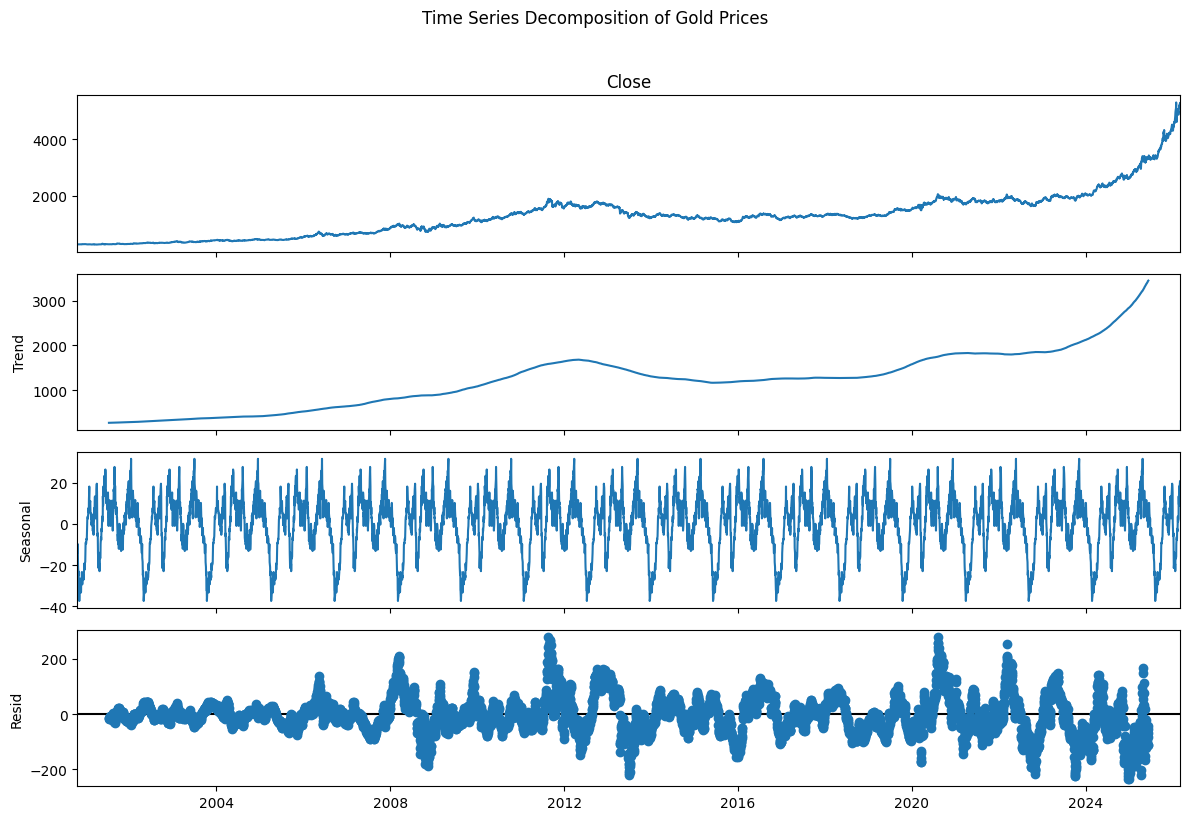

In [109]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt


decomposition = seasonal_decompose(series, model='additive', period=365)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition of Gold Prices', y=1.02)
plt.tight_layout()
plt.show()


## Implement ARIMA Model



In [110]:
from statsmodels.tsa.arima.model import ARIMA
print("ARIMA class imported successfully.")

ARIMA class imported successfully.


In [111]:
df_arima = df.copy()
df_arima.set_index('Date', inplace=True)
# Select the 'Close' price as the series for ARIMA modeling
series = df_arima['Close']

# Prepare exogenous variables for ARIMA
exog_features_arima = ['DXY_Close', 'DXY_Lag1', 'DXY_Lag2']
exog_arima = df_arima[exog_features_arima]

print("Data prepared for ARIMA model with 'Date' as index and 'Close' as the series.")
print(series.head())
print("Exogenous features for ARIMA:")
print(exog_arima.head())

Data prepared for ARIMA model with 'Date' as index and 'Close' as the series.
Date
2000-10-19    270.100006
2000-10-20    271.200012
2000-10-23    270.100006
2000-10-24    270.100006
2000-10-25    266.200012
Name: Close, dtype: float64
Exogenous features for ARIMA:
             DXY_Close    DXY_Lag1    DXY_Lag2
Date                                          
2000-10-19  116.940002  117.330002  115.889999
2000-10-20  117.160004  116.940002  117.330002
2000-10-23  117.540001  117.160004  116.940002
2000-10-24  117.419998  117.540001  117.160004
2000-10-25  118.489998  117.419998  117.540001


In [112]:
split_point_arima = int(len(series) * 0.8)
train_arima = series[:split_point_arima]
test_arima = series[split_point_arima:]

exog_train_arima = exog_arima[:split_point_arima]
exog_test_arima = exog_arima[split_point_arima:]

print(f"Training set size: {len(train_arima)}")
print(f"Testing set size: {len(test_arima)}")
print(f"Exogenous training set shape: {exog_train_arima.shape}")
print(f"Exogenous testing set shape: {exog_test_arima.shape}")
print("Data split into training and testing sets for ARIMA model, including exogenous variables.")

Training set size: 5088
Testing set size: 1272
Exogenous training set shape: (5088, 3)
Exogenous testing set shape: (1272, 3)
Data split into training and testing sets for ARIMA model, including exogenous variables.


In [113]:
print("Training ARIMA model...")

arima_order = (5, 1, 0) # A common starting point for ARIMA models

# Fit the ARIMA model to the training data, now including exogenous variables
arima_model = ARIMA(train_arima, order=arima_order, exog=exog_train_arima)
arima_model_fit = arima_model.fit()

print("ARIMA model training complete.")
print(arima_model_fit.summary())

Training ARIMA model...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA model training complete.
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 5088
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -19839.211
Date:                Thu, 12 Mar 2026   AIC                          39696.422
Time:                        05:47:28   BIC                          39755.232
Sample:                             0   HQIC                         39717.016
                               - 5088                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
DXY_Close     -8.8464      0.314    -28.214      0.000      -9.461      -8.232
DXY_Lag1      -1.3962      0.353     -3.958      0.000      -2.088      -0.705
DXY_Lag2       0.4368

In [106]:
print("Making predictions with ARIMA model...")

arima_predictions = arima_model_fit.predict(start=len(train_arima), end=len(series)-1, exog=exog_test_arima)

# Ensure predictions have the same index as the test set for easier comparison
arima_predictions.index = test_arima.index
print("ARIMA predictions complete.")

# Evaluate the ARIMA model
mae_arima = mean_absolute_error(test_arima, arima_predictions)
mse_arima = mean_squared_error(test_arima, arima_predictions)
rmse_arima = mse_arima**0.5
r2_arima = r2_score(test_arima, arima_predictions)

print(f"\nARIMA Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae_arima:.2f}")
print(f"Mean Squared Error (MSE): {mse_arima:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_arima:.2f}")
print(f"R-squared (R2): {r2_arima:.2f}")

Making predictions with ARIMA model...
ARIMA predictions complete.

ARIMA Model Evaluation Metrics:
Mean Absolute Error (MAE): 658.43
Mean Squared Error (MSE): 1068573.02
Root Mean Squared Error (RMSE): 1033.72
R-squared (R2): -0.65


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### Visualizing ARIMA Model Predictions vs. Actual Values and Compare with Random Forest

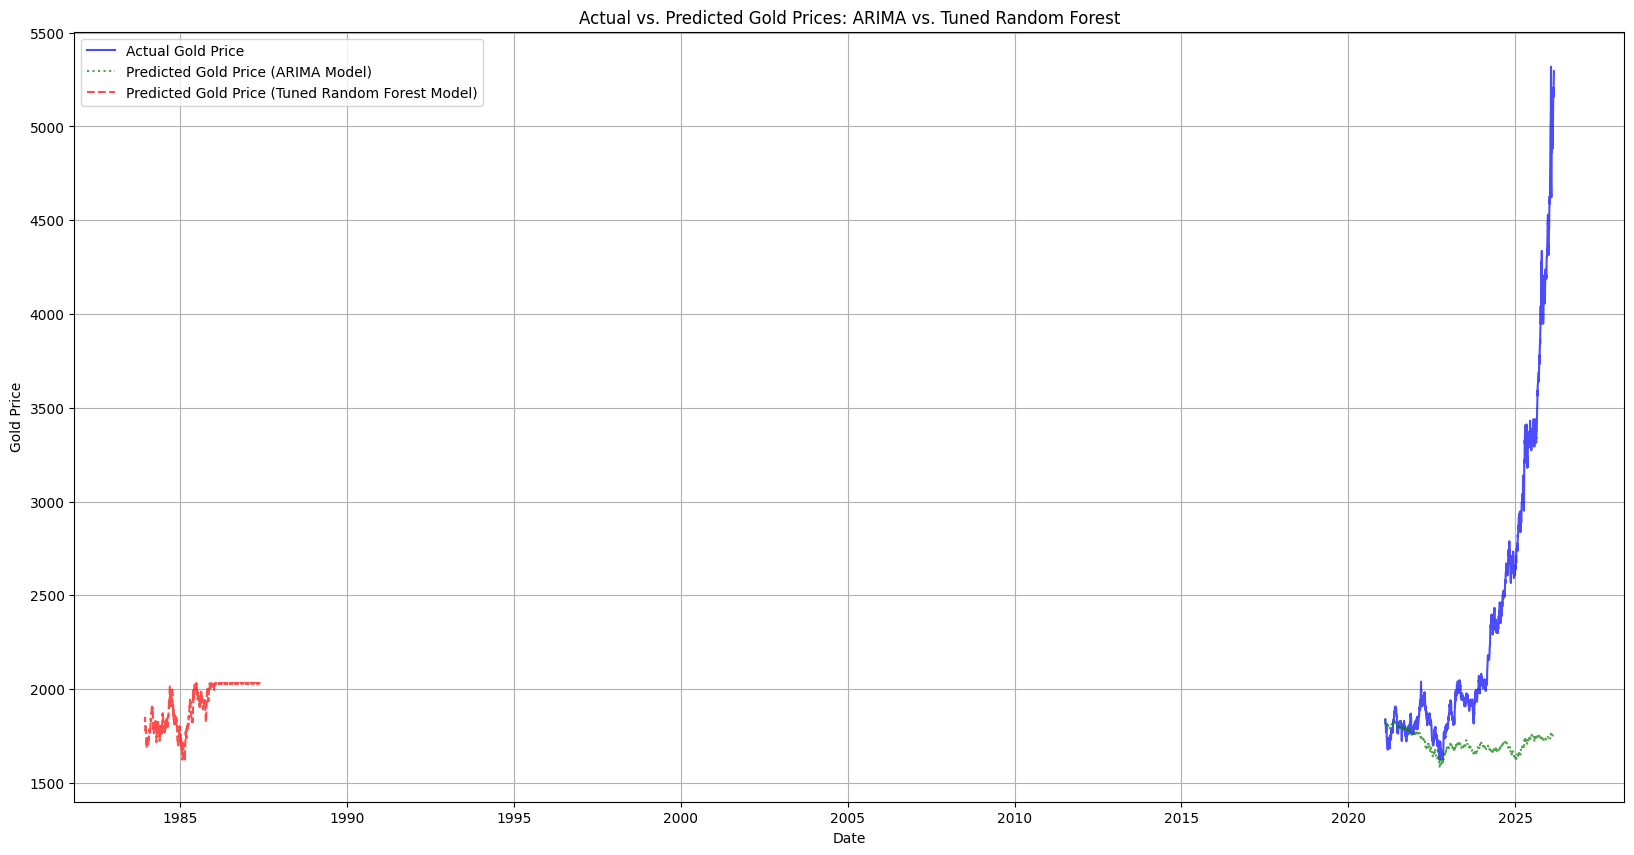

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

# Plot Actual Gold Price
plt.plot(test_arima.index, test_arima, label='Actual Gold Price', color='blue', alpha=0.7)

# Plot ARIMA Predictions
plt.plot(arima_predictions.index, arima_predictions, label='Predicted Gold Price (ARIMA Model)', color='green', linestyle=':', alpha=0.7)


plt.plot(y_test.index, y_pred_tuned, label='Predicted Gold Price (Tuned Random Forest Model)', color='red', linestyle='--', alpha=0.7)

plt.title('Actual vs. Predicted Gold Prices: ARIMA vs. Tuned Random Forest')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.show()

In [98]:
import yfinance as yf
import numpy as np
import pandas as pd # Ensure pandas is imported

# Download DXY data
# 'DX-Y.NYB' is often used as a ticker for the ICE US Dollar Index futures on Yahoo Finance
# Adjust start and end dates to cover the full range of your gold data
# We will use 'Close' price from df to get the start and end dates

start_date = df['Date'].min()
end_date = df['Date'].max()

dxy_df = yf.download('DX-Y.NYB', start=start_date, end=end_date)

# --- FIX: Flatten MultiIndex columns if present ---
if isinstance(dxy_df.columns, pd.MultiIndex):
    dxy_df.columns = dxy_df.columns.droplevel(1) # Drop the ticker symbol level
# --- END FIX ---

# Reset index to make 'Date' a column
dxy_df.reset_index(inplace=True)

# Determine which column to use for DXY_Close: 'Adj Close' or 'Close'
if 'Adj Close' in dxy_df.columns:
    dxy_df.rename(columns={'Adj Close': 'DXY_Close'}, inplace=True)
elif 'Close' in dxy_df.columns:
    dxy_df.rename(columns={'Close': 'DXY_Close'}, inplace=True)
else:
    raise ValueError("Neither 'Adj Close' nor 'Close' column found in DXY data.")

# Select relevant columns after ensuring DXY_Close exists
dxy_df = dxy_df[['Date', 'DXY_Close']]

# Display the first few rows of DXY data
print("\nUS Dollar Index (DXY) Data Head:")
print(dxy_df.head())

# --- FIX: Drop existing DXY columns from df before merge to prevent suffix issues ---
existing_dxy_cols = [col for col in df.columns if 'DXY' in col]
if existing_dxy_cols:
    df.drop(columns=existing_dxy_cols, inplace=True)
# --- END FIX ---

# Merge DXY data with the main DataFrame
# Use a left merge to keep all gold data and add DXY where available
df = pd.merge(df, dxy_df, on='Date', how='left')

# Check if 'DXY_Close' exists after merge before attempting fillna
if 'DXY_Close' not in df.columns:
    raise KeyError("DXY_Close column not found in df after merge. Merge might have failed or dxy_df was empty.")

# Handle missing DXY values after merge (e.g., fill with forward fill then backward fill)
# Using ffill() and bfill() directly as fillna(method=...) is deprecated
df['DXY_Close'] = df['DXY_Close'].ffill()
df['DXY_Close'] = df['DXY_Close'].bfill()


# Create lagged features for DXY_Close as well
df['DXY_Lag1'] = df['DXY_Close'].shift(1)
df['DXY_Lag2'] = df['DXY_Close'].shift(2)

# Drop rows with NaN values resulting from lagged DXY features
df.dropna(inplace=True)

print("\nDataFrame after merging with DXY and feature engineering:")
print(df.head())
print(f"New DataFrame shape: {df.shape}")

/tmp/ipykernel_246/2892372848.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dxy_df = yf.download('DX-Y.NYB', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


US Dollar Index (DXY) Data Head:
Price       Date   DXY_Close
0     2000-10-17  115.889999
1     2000-10-18  117.330002
2     2000-10-19  116.940002
3     2000-10-20  117.160004
4     2000-10-23  117.540001

DataFrame after merging with DXY and feature engineering:
        Date        Open        High         Low       Close  Volume  Year  \
2 2000-10-19  270.100006  270.100006  270.100006  270.100006       1  2000   
3 2000-10-20  271.200012  271.200012  271.200012  271.200012      32  2000   
4 2000-10-23  271.700012  271.700012  270.100006  270.100006       1  2000   
5 2000-10-24  269.799988  270.100006  269.799988  270.100006      16  2000   
6 2000-10-25  266.200012  267.100006  266.000000  266.200012      20  2000   

   Month  Day  DayOfWeek  ...  Close_Lag3  Close_Lag4  Close_Lag5  \
2     10   19          3  ...  271.500000  272.399994  276.399994   
3     10   20          4  ...  271.100006  271.500000  272.399994   
4     10   23          0  ...  270.299988  271.100006  27